  NGC4698: 283391 HII pixels


/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_82926/1620638054.py:171: RuntimeWarning: divide by zero encountered in divide
  logN2_hii = np.log10(NII_common_HII / HA_common_HII)
/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_82926/1620638054.py:173: RuntimeWarning: divide by zero encountered in divide
  logO3_hii = np.log10(OIII_common_HII / HB_common_HII)
/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_82926/1620638054.py:173: RuntimeWarning: divide by zero encountered in log10
  logO3_hii = np.log10(OIII_common_HII / HB_common_HII)
/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_82926/1620638054.py:175: RuntimeWarning: divide by zero encountered in divide
  logS2_hii = np.log10((SII6716_common_HII + SII6730_common_HII) / HA_common_HII)
/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_82926/1620638054.py:175: RuntimeWarning: divide by zero encountered in log10
  logS2_hii = np.log10((SII6716_common_HII + SII6730_common_HII) / H


Total combined HII pixels: 283391

=== Combined BPT Diagram Summary (HII only) ===
  N2 BPT - Total HII: 154289 (54.4%)
  S2 BPT - Total HII: 80659 (28.5%)

Galaxy breakdown for HII spaxels:
  NGC4698: N2_HII=154289, S2_HII=80659

Successfully created combined BPT diagrams (HII only) colored by galaxy from 1 galaxies
Galaxies included: NGC4698


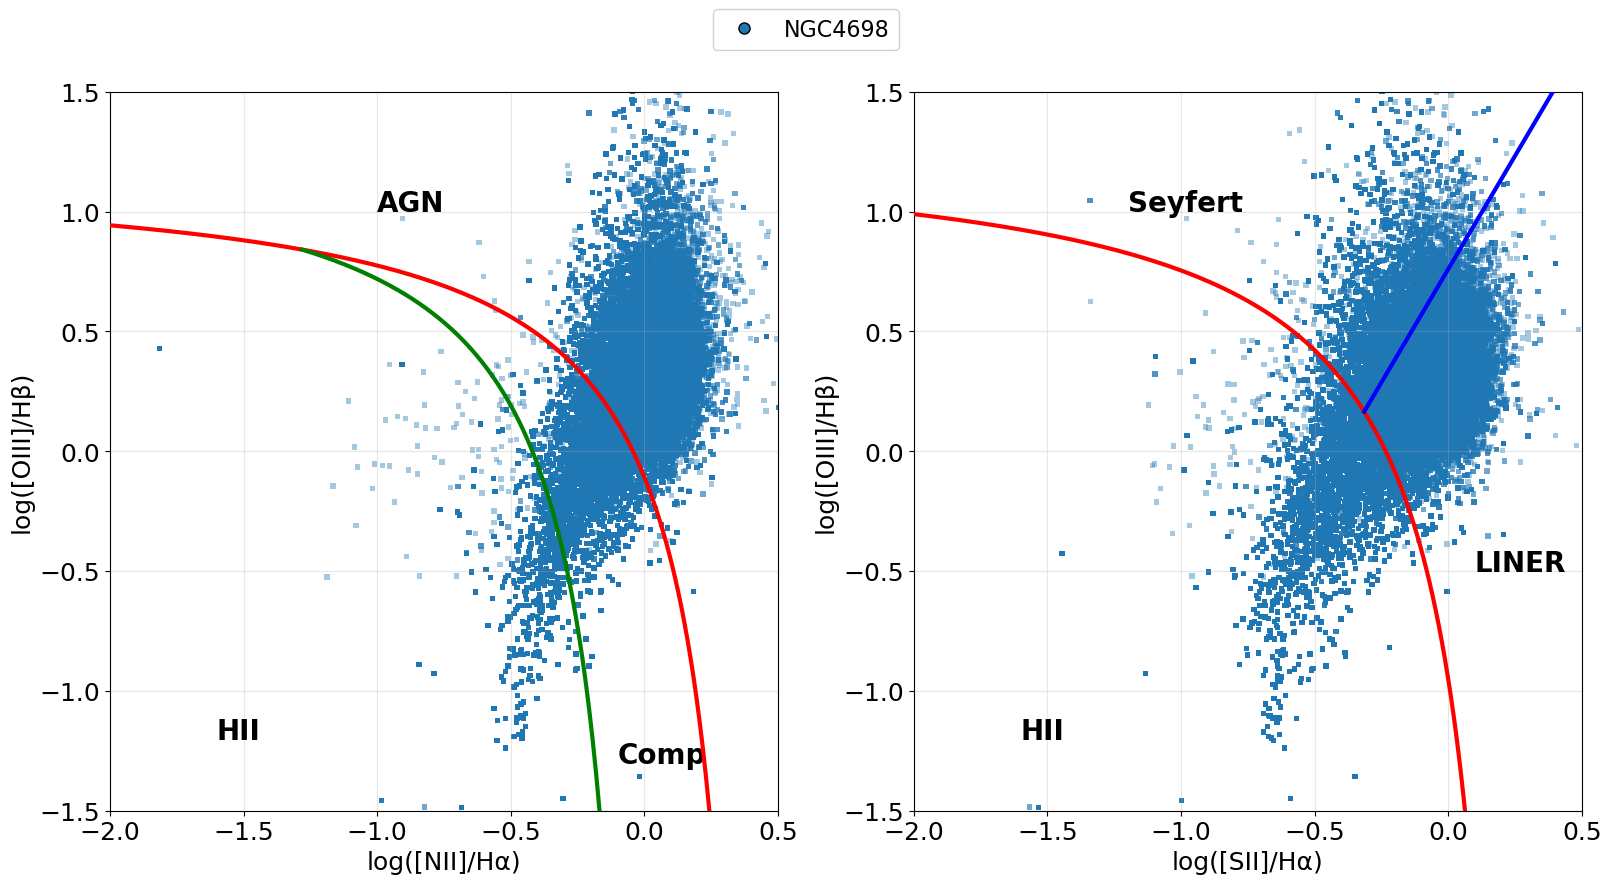

In [1]:
# ------------------------------------------------------------------

# Combined Analysis: NII and SII BPT Diagrams - Color-coded by Galaxy

# Collect all HII spaxels from all galaxies (HII only, no SF)

# Uses common spaxels across all 4 metallicity calibrations

# ------------------------------------------------------------------

import numpy as np

import matplotlib.pyplot as plt

from matplotlib.lines import Line2D

from pathlib import Path

from astropy.io import fits



# BPT reference line functions

def kewley01_N2(x):   # max-starburst

    return 0.61/(x-0.47) + 1.19



def kauff03_N2(x):    # empirical SF upper envelope

    return 0.61/(x-0.05) + 1.30



def kewley01_S2(x):

    return 0.72/(x-0.32) + 1.30



def kewley06_Sy_LIN(x):   # Seyfert/LINER division

    return 1.89*x + 0.76



# Create x arrays for the theoretical lines

x_kewley_N2 = np.linspace(-2.0, 0.3, 200)

x_kauff_N2 = np.linspace((286-np.sqrt(2871561))/1100, 0.0, 200)

x_kewley_S2 = np.linspace(-2.0, 0.3, 200)

x_kewley06_S2 = np.linspace((159-np.sqrt(105081))/525, 0.5, 200)



# Get all galaxies from binning files

bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))

galaxies = [f.name.split('_')[0] for f in bins]
galaxies = ['NGC4698']


# Create galaxy color mapping (consistent for all HII regions)

galaxy_colors = plt.cm.tab20(np.linspace(0, 1, len(galaxies)))

galaxy_color_dict = dict(zip(galaxies, galaxy_colors))



# Collect all spaxels from all galaxies - HII only (with galaxy indices)

all_logN2_hii = []

all_logO3_hii = []

all_logS2_hii = []

all_galaxy_indices_hii = []



print("Collecting HII data from all galaxies...")

for gal_idx, gal in enumerate(galaxies):

    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')



    if gas_file.exists() and bin_file.exists():

        # Load maps for this galaxy

        with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:

            logSigmaM = h['LOGMASS_SURFACE_DENSITY'].data

        with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:

            # HII quantities

            logSigmaSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data

            oh_d16_HII = h['O_H_D16_HII'].data

            oh_pg16_HII = h['O_H_PG16_HII'].data

            oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data

            oh_o3n2_c20_HII = h['O_H_O3N2_C20_HII'].data



            # Load corrected emission line fluxes

            HB4861_FLUX_corr = h['HB4861_FLUX_corr'].data

            HA6562_FLUX_corr = h['HA6562_FLUX_corr'].data

            OIII5006_FLUX_corr = h['OIII5006_FLUX_corr'].data

            NII6583_FLUX_corr = h['NII6583_FLUX_corr'].data

            SII6716_FLUX_corr = h['SII6716_FLUX_corr'].data

            SII6730_FLUX_corr = h['SII6730_FLUX_corr'].data



        # Find common spaxels for HII

        common_mask_HII = (np.isfinite(HB4861_FLUX_corr) & np.isfinite(HA6562_FLUX_corr) &
                           np.isfinite(OIII5006_FLUX_corr) & np.isfinite(NII6583_FLUX_corr) &
                           np.isfinite(SII6716_FLUX_corr) & np.isfinite(SII6730_FLUX_corr))



        n_pixels_HII = np.sum(common_mask_HII)

        print(f"  {gal}: {n_pixels_HII} HII pixels")



        # Apply common_mask to get valid spaxels - HII

        HB_common_HII = HB4861_FLUX_corr[common_mask_HII]

        HA_common_HII = HA6562_FLUX_corr[common_mask_HII]

        OIII_common_HII = OIII5006_FLUX_corr[common_mask_HII]

        NII_common_HII = NII6583_FLUX_corr[common_mask_HII]

        SII6716_common_HII = SII6716_FLUX_corr[common_mask_HII]

        SII6730_common_HII = SII6730_FLUX_corr[common_mask_HII]



        # Calculate line ratios - HII

        logN2_hii = np.log10(NII_common_HII / HA_common_HII)

        logO3_hii = np.log10(OIII_common_HII / HB_common_HII)

        logS2_hii = np.log10((SII6716_common_HII + SII6730_common_HII) / HA_common_HII)



        # Append to combined arrays - HII only

        all_logN2_hii.extend(logN2_hii.flatten())

        all_logO3_hii.extend(logO3_hii.flatten())

        all_logS2_hii.extend(logS2_hii.flatten())

        all_galaxy_indices_hii.extend([gal_idx] * len(logN2_hii.flatten()))

    else:

        print(f"  {gal}: Data files not found")



# Convert to numpy arrays - HII

all_logN2_hii = np.array(all_logN2_hii)

all_logO3_hii = np.array(all_logO3_hii)

all_logS2_hii = np.array(all_logS2_hii)

all_galaxy_indices_hii = np.array(all_galaxy_indices_hii)



print(f"\nTotal combined HII pixels: {len(all_logN2_hii)}")



# Apply BPT classifications - HII only

mask_N2_HII = all_logO3_hii <= kauff03_N2(all_logN2_hii)

mask_N2_Comp = (all_logO3_hii > kauff03_N2(all_logN2_hii)) & (all_logO3_hii <= kewley01_N2(all_logN2_hii))

mask_N2_AGN = all_logO3_hii > kewley01_N2(all_logN2_hii)



mask_S2_HII = all_logO3_hii <= kewley01_S2(all_logS2_hii)

mask_S2_above_kewley = all_logO3_hii > kewley01_S2(all_logS2_hii)

mask_S2_LINER = mask_S2_above_kewley & (all_logO3_hii <= kewley06_Sy_LIN(all_logS2_hii))

mask_S2_Seyfert = mask_S2_above_kewley & (all_logO3_hii > kewley06_Sy_LIN(all_logS2_hii))



mask_HII_N2 = mask_N2_HII | mask_N2_Comp

mask_HII_S2 = mask_S2_HII



# Create BPT diagrams: HII only (single row, two panels)

# Use constrained_layout for better spacing with legend

fig, axes = plt.subplots(1, 2, figsize=(16, 8), constrained_layout=True)



# ===== HII REGIONS ONLY =====



# NII BPT Diagram - HII

ax = axes[0]



for gal_idx, gal in enumerate(galaxies):

    gal_mask = (all_galaxy_indices_hii == gal_idx)
    if np.sum(gal_mask) > 0:

        ax.scatter(all_logN2_hii[gal_mask], all_logO3_hii[gal_mask], 

                   color=galaxy_colors[gal_idx], marker=',', s=15, alpha=0.4, 

                   edgecolors='none', rasterized=True)



ax.plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'r-', lw=3, label='Kewley+01', zorder=10)

ax.plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'g-', lw=3, label='Kauffmann+03', zorder=10)



hii_count_N2 = np.sum(mask_HII_N2)

total_common_hii = len(all_logN2_hii)

hii_percent_N2 = hii_count_N2 / total_common_hii * 100 if total_common_hii > 0 else 0



ax.set_xlabel('log([NII]/Hα)', fontsize=18)

ax.set_ylabel('log([OIII]/Hβ)', fontsize=18)

ax.tick_params(axis='both', which='major', labelsize=18)

ax.set_xlim(-2.0, 0.5)

ax.set_ylim(-1.5, 1.5)

# ax.set_title('NII BPT (Common HII spaxels by Galaxy)', fontsize=14)

ax.text(-1.6, -1.2, 'HII', fontsize=20, fontweight='bold')

ax.text(-0.1, -1.3, 'Comp', fontsize=20, fontweight='bold')

ax.text(-1.0, 1.0, 'AGN', fontsize=20, fontweight='bold')

ax.grid(True, alpha=0.3)



# SII BPT Diagram - HII

ax = axes[1]



for gal_idx, gal in enumerate(galaxies):

    gal_mask = (all_galaxy_indices_hii == gal_idx)
    if np.sum(gal_mask) > 0:

        ax.scatter(all_logS2_hii[gal_mask], all_logO3_hii[gal_mask], 

                   color=galaxy_colors[gal_idx], marker=',', s=15, alpha=0.4, 

                   edgecolors='none', rasterized=True)



ax.plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'r-', lw=3, label='Kewley+01', zorder=10)

ax.plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'b-', lw=3, label='Kewley+06', zorder=10)



hii_count_S2 = np.sum(mask_HII_S2)

hii_percent_S2 = hii_count_S2 / total_common_hii * 100 if total_common_hii > 0 else 0



ax.set_xlabel('log([SII]/Hα)', fontsize=18)

ax.set_ylabel('log([OIII]/Hβ)', fontsize=18)

ax.tick_params(axis='both', which='major', labelsize=18)

ax.set_xlim(-2.0, 0.5)

ax.set_ylim(-1.5, 1.5)

# ax.set_title('SII BPT (Common HII spaxels by Galaxy)', fontsize=14)

ax.text(-1.6, -1.2, 'HII', fontsize=20, fontweight='bold')

ax.text(-1.2, 1.0, 'Seyfert', fontsize=20, fontweight='bold')

ax.text(0.1, -0.5, 'LINER', fontsize=20, fontweight='bold')

ax.grid(True, alpha=0.3)



# Build custom legend handles with larger markers

legend_handles = []

legend_labels = []

for gal_idx, gal in enumerate(galaxies):

    legend_handles.append(Line2D([0], [0], marker='o', color='none', 

                                 markerfacecolor=galaxy_colors[gal_idx], markersize=8, linestyle='None'))

    legend_labels.append(f'{gal}')



# Put legend above the axes at 1.1 (outside plot)

fig.legend(legend_handles, legend_labels, loc='upper center',

           bbox_to_anchor=(0.5, 1.1),

           ncol=min(len(legend_labels), 7), fontsize=16, framealpha=0.9)



# Save PNG tightly cropped, PDF with standard bbox (no cropping of legend)

# fig.savefig('Plot_Paper_1/Combined_BPT_diagrams_by_Galaxy_HII.png', dpi=600, bbox_inches='tight', pad_inches=0.05)

# fig.savefig('Plot_Paper_1/Combined_BPT_diagrams_by_Galaxy_HII.pdf', dpi=600, bbox_inches='tight', pad_inches=0.05)



# Print summary statistics (HII only)

print(f"\n=== Combined BPT Diagram Summary (HII only) ===")

print(f"  N2 BPT - Total HII: {hii_count_N2} ({hii_percent_N2:.1f}%)")

print(f"  S2 BPT - Total HII: {hii_count_S2} ({hii_percent_S2:.1f}%)")



# Print galaxy breakdown for HII spaxels

print(f"\nGalaxy breakdown for HII spaxels:")

for gal_idx, gal in enumerate(galaxies):

    gal_n2 = np.sum((all_galaxy_indices_hii == gal_idx) & mask_HII_N2)

    gal_s2 = np.sum((all_galaxy_indices_hii == gal_idx) & mask_HII_S2)

    print(f"  {gal}: N2_HII={gal_n2}, S2_HII={gal_s2}")



print(f"\nSuccessfully created combined BPT diagrams (HII only) colored by galaxy from {len(galaxies)} galaxies")

print(f"Galaxies included: {', '.join(galaxies)}")

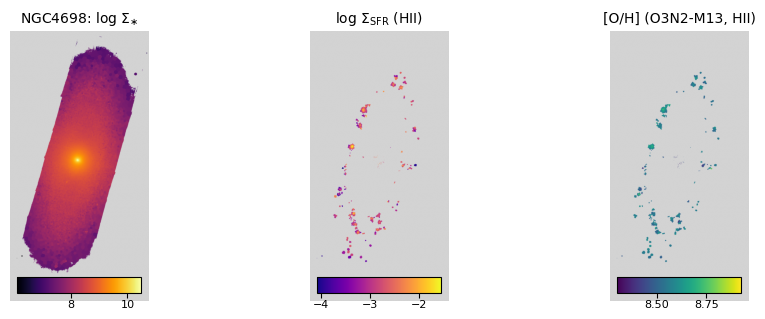

In [2]:
# --------------------------------------------------------------
# Maps: Σ_M*, Σ_SFR and [O/H] (O3N2-M13) maps for a single galaxy
# Using HII spaxels (common HII for Σ_SFR and O/H only)
# Layout: 1 row × 3 columns: [Σ_M*, Σ_SFR, [O/H]]
# --------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from astropy.io import fits

# 0 · select galaxy
galaxies = ['NGC4698']
ngal     = len(galaxies)
assert ngal == 1, "This cell is configured for a single galaxy."

# 1 · helpers to load maps (no mask for mass; HII mask for Σ_SFR and O/H)
def load_maps_hii(gal):
    """
    Load stellar-mass surface density (from spatial-binning file),
    Σ_SFR (HII), and [O/H] (O3N2-M13, HII) for a galaxy.

    - Σ_M* is shown wherever it is finite (no HII mask).
    - Σ_SFR and [O/H] use a common HII mask requiring both to be finite.
    """
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h_bin:
        logSigmaM = h_bin['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h_gas:
        sigSFR_HII     = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_o3n2m13_HII = h_gas['O_H_O3N2_M13_HII'].data

    # Mass: just require Σ_M* to be finite
    mass_mask   = np.isfinite(logSigmaM)
    logSigmaM_c = np.where(mass_mask, logSigmaM, np.nan)

    # HII common mask for Σ_SFR and O/H
    hii_mask        = (np.isfinite(sigSFR_HII) & np.isfinite(oh_o3n2m13_HII))
    sigSFR_HII_c    = np.where(hii_mask, sigSFR_HII, np.nan)
    oh_o3n2m13_c    = np.where(hii_mask, oh_o3n2m13_HII, np.nan)

    return logSigmaM_c, sigSFR_HII_c, oh_o3n2m13_c

# 2 · figure & GridSpec (1 row × 3 columns)
fig = plt.figure(figsize=(9, 3), constrained_layout=True)
gs  = GridSpec(
        nrows=1, ncols=3, figure=fig,
        width_ratios=[1, 1, 1],
        wspace=0.00, hspace=0.00
)

gal = galaxies[0]
logSigmaM_c, sigSFR_HII_c, oh_o3n2m13_c = load_maps_hii(gal)

# Σ_M* map with NaN shown as light gray
axM = fig.add_subplot(gs[0, 0])
cmap_M = plt.cm.inferno.copy(); cmap_M.set_bad('lightgray')
imM = axM.imshow(logSigmaM_c, origin='lower', cmap=cmap_M)
axM.set_title(rf'{gal}: $\log\,\Sigma_{{\ast}}$', fontsize=10)
axM.axis('off')
caxM = inset_axes(axM, width='90%', height='6%', loc='lower center', borderpad=0.6)
fig.colorbar(imM, cax=caxM, orientation='horizontal')
caxM.tick_params(labelsize=8, pad=1)

# Σ_SFR (HII) map with NaN shown as light gray
axS = fig.add_subplot(gs[0, 1])
cmap_S = plt.cm.plasma.copy(); cmap_S.set_bad('lightgray')
imS = axS.imshow(sigSFR_HII_c, origin='lower', cmap=cmap_S)
axS.set_title(r'$\log\,\Sigma_{\mathrm{SFR}}$ (HII)', fontsize=10)
axS.axis('off')
caxS = inset_axes(axS, width='90%', height='6%', loc='lower center', borderpad=0.6)
fig.colorbar(imS, cax=caxS, orientation='horizontal')
caxS.tick_params(labelsize=8, pad=1)

# [O/H] O3N2-M13 (HII) map with NaN shown as light gray
axOH = fig.add_subplot(gs[0, 2])
cmap_OH = plt.cm.viridis.copy(); cmap_OH.set_bad('lightgray')
imOH = axOH.imshow(oh_o3n2m13_c, origin='lower', cmap=cmap_OH)
axOH.set_title(r'[O/H] (O3N2-M13, HII)', fontsize=10)
axOH.axis('off')
caxOH = inset_axes(axOH, width='90%', height='6%', loc='lower center', borderpad=0.6)
fig.colorbar(imOH, cax=caxOH, orientation='horizontal')
caxOH.tick_params(labelsize=8, pad=1)

# Save figure in both PNG and PDF formats
# fig.savefig('Plot_Paper_1/NGC4698_SigmaM_SigmaSFR_OH_Maps_HII_1x3.png', dpi=600, bbox_inches='tight', pad_inches=0.05)
# fig.savefig('Plot_Paper_1/NGC4698_SigmaM_SigmaSFR_OH_Maps_HII_1x3.pdf', dpi=600, bbox_inches='tight', pad_inches=0.05)

plt.show()

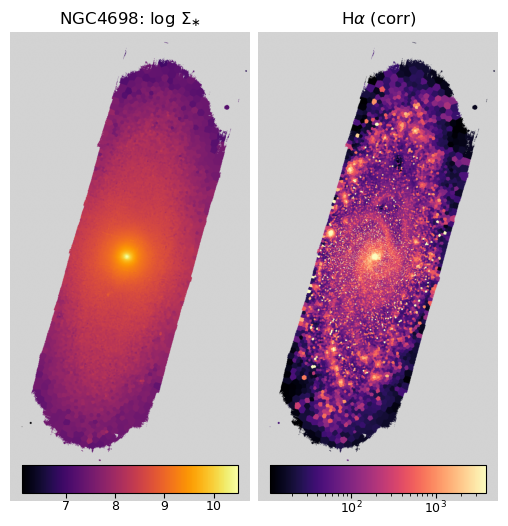

In [3]:
# --------------------------------------------------------------
# Maps: Σ_M* and corrected Hα flux for a single galaxy
# Data sources:
#  - Σ_M*: LOGMASS_SURFACE_DENSITY from *_SPATIAL_BINNING_maps_extended.fits
#  - Hα (corr): HA6562_FLUX_CORR (or HA6562_FLUX_corr) from *_gas_BIN_maps_extended.fits
# Layout: 1 row × 2 columns: [Σ_M*, Hα_corr]
# --------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.colors import LogNorm
from astropy.io import fits

# 0 · select galaxy
galaxies = ['NGC4698']
assert len(galaxies) == 1, "This cell is configured for a single galaxy."
gal = galaxies[0]

def load_mass_and_halpha_corr(gal):
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h_bin:
        logSigmaM = h_bin['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h_gas:
        # Try both common HDU name conventions (case varies across files)
        if 'HA6562_FLUX_CORR' in h_gas:
            ha_corr = h_gas['HA6562_FLUX_CORR'].data
        elif 'HA6562_FLUX_corr' in h_gas:
            ha_corr = h_gas['HA6562_FLUX_corr'].data
        else:
            raise KeyError("Cannot find Hα HDU: expected 'HA6562_FLUX_CORR' or 'HA6562_FLUX_corr'.")

    logSigmaM_c = np.where(np.isfinite(logSigmaM), logSigmaM, np.nan)
    ha_corr_c   = np.where(np.isfinite(ha_corr), ha_corr, np.nan)
    return logSigmaM_c, ha_corr_c

logSigmaM_c, ha_corr_c = load_mass_and_halpha_corr(gal)

# For log colorbar, mask non-positive values (log undefined there)
ha_corr_log = np.where(ha_corr_c > 0, ha_corr_c, np.nan)

# 1 row × 2 columns; make figure large enough for publication-style viewing
fig = plt.figure(figsize=(12, 5), constrained_layout=True)
gs  = GridSpec(nrows=1, ncols=2, figure=fig, width_ratios=[1, 1], wspace=0.00, hspace=0.00)

# Σ_M*
axM = fig.add_subplot(gs[0, 0])
cmap_M = plt.cm.inferno.copy(); cmap_M.set_bad('lightgray')
imM = axM.imshow(logSigmaM_c, origin='lower', cmap=cmap_M)
axM.set_title(rf'{gal}: $\log\,\Sigma_{{\ast}}$', fontsize=12)
axM.axis('off')
axM.set_anchor('E')  # push left panel to the right edge of its cell
caxM = inset_axes(axM, width='90%', height='6%', loc='lower center', borderpad=0.6)
fig.colorbar(imM, cax=caxM, orientation='horizontal')
caxM.tick_params(labelsize=9, pad=1)

# Hα (corrected flux) with log-scaled colorbar
axHa = fig.add_subplot(gs[0, 1])
cmap_Ha = plt.cm.magma.copy(); cmap_Ha.set_bad('lightgray')

valid = np.isfinite(ha_corr_log)
if np.any(valid):
    vmin = np.nanpercentile(ha_corr_log[valid], 1)
    vmax = np.nanpercentile(ha_corr_log[valid], 99)
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin <= 0 or vmax <= vmin:
        # Fallback (still log) if percentiles are degenerate
        vmin = np.nanmin(ha_corr_log[valid])
        vmax = np.nanmax(ha_corr_log[valid])
    imHa = axHa.imshow(ha_corr_log, origin='lower', cmap=cmap_Ha, norm=LogNorm(vmin=vmin, vmax=vmax))
else:
    # Nothing positive/finite to show on a log scale; fall back to linear display
    print('Warning: No positive finite Hα values; using linear scale.')
    imHa = axHa.imshow(ha_corr_c, origin='lower', cmap=cmap_Ha)

axHa.set_title(r'H$\alpha$ (corr)', fontsize=12)
axHa.axis('off')
axHa.set_anchor('W')  # push right panel to the left edge of its cell
caxHa = inset_axes(axHa, width='90%', height='6%', loc='lower center', borderpad=0.6)
fig.colorbar(imHa, cax=caxHa, orientation='horizontal')
caxHa.tick_params(labelsize=9, pad=1)

# fig.savefig('Plot_Paper_1/NGC4698_SigmaM_HalphaCorr_Maps_1x2.png', dpi=600, bbox_inches='tight', pad_inches=0.05)
# fig.savefig('Plot_Paper_1/NGC4698_SigmaM_HalphaCorr_Maps_1x2.pdf', dpi=600, bbox_inches='tight', pad_inches=0.05)

plt.show()

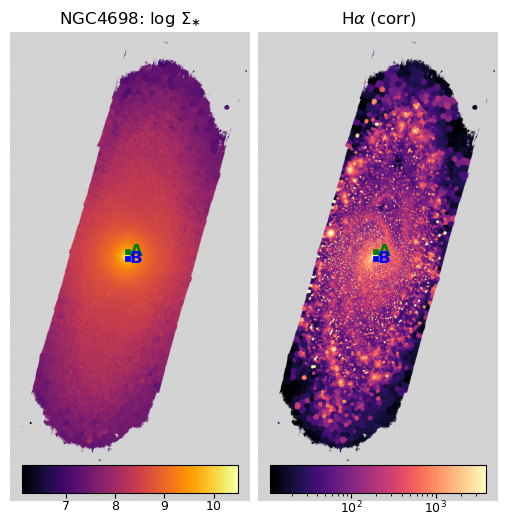

In [4]:
# --------------------------------------------------------------
# Maps: Σ_M* and corrected Hα flux for a single galaxy + boxed regions
# Data sources:
#  - Σ_M*: LOGMASS_SURFACE_DENSITY from *_SPATIAL_BINNING_maps_extended.fits
#  - Hα (corr): HA6562_FLUX_CORR (or HA6562_FLUX_corr) from *_gas_BIN_maps_extended.fits
# Overlays: two 8×8 spaxel (0.2"/spaxel) regions centered at specified WCS coords
# Layout: 1 row × 2 columns: [Σ_M*, Hα_corr]
# --------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.colors import LogNorm
from matplotlib.patches import Rectangle
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u

# 0 · select galaxy
galaxies = ['NGC4698']
assert len(galaxies) == 1, "This cell is configured for a single galaxy."
gal = galaxies[0]

# Region definitions (centers)
coord_A = SkyCoord('12:48:22.89', '8:29:17.7', unit=(u.hourangle, u.deg), frame='icrs')
coord_B = SkyCoord('12:48:22.89', '8:29:14.2', unit=(u.hourangle, u.deg), frame='icrs')

# Each region: 8×8 spaxels (spaxel size 0.2") → use 8×8 pixels in the map grid
box_size_pix = 8
half_box = box_size_pix / 2

def load_mass_and_halpha_corr_and_wcs(gal):
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h_bin:
        logSigmaM = h_bin['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h_gas:
        # Try both common HDU name conventions (case varies across files)
        if 'HA6562_FLUX_CORR' in h_gas:
            ha_hdu = h_gas['HA6562_FLUX_CORR']
        elif 'HA6562_FLUX_corr' in h_gas:
            ha_hdu = h_gas['HA6562_FLUX_corr']
        else:
            raise KeyError("Cannot find Hα HDU: expected 'HA6562_FLUX_CORR' or 'HA6562_FLUX_corr'.")
        ha_corr = ha_hdu.data
        wcs = WCS(ha_hdu.header).celestial

    logSigmaM_c = np.where(np.isfinite(logSigmaM), logSigmaM, np.nan)
    ha_corr_c   = np.where(np.isfinite(ha_corr), ha_corr, np.nan)
    return logSigmaM_c, ha_corr_c, wcs

logSigmaM_c, ha_corr_c, wcs_cel = load_mass_and_halpha_corr_and_wcs(gal)

# For log colorbar, mask non-positive values (log undefined there)
ha_corr_log = np.where(ha_corr_c > 0, ha_corr_c, np.nan)

# Convert region centers from WCS → pixel coords (x, y)
xA, yA = wcs_cel.world_to_pixel(coord_A)
xB, yB = wcs_cel.world_to_pixel(coord_B)

def add_box(ax, x_center, y_center, label, color):
    rect = Rectangle(
        (x_center - half_box, y_center - half_box),
        box_size_pix, box_size_pix,
        fill=False, edgecolor=color, linewidth=2
    )
    ax.add_patch(rect)
    ax.text(x_center + half_box + 1, y_center, label, color=color, fontsize=12, weight='bold', va='center')

# 1 row × 2 columns; make figure large enough for publication-style viewing
fig = plt.figure(figsize=(12, 5), constrained_layout=True)
gs  = GridSpec(nrows=1, ncols=2, figure=fig, width_ratios=[1, 1], wspace=0.00, hspace=0.00)

# Σ_M*
axM = fig.add_subplot(gs[0, 0])
cmap_M = plt.cm.inferno.copy(); cmap_M.set_bad('lightgray')
imM = axM.imshow(logSigmaM_c, origin='lower', cmap=cmap_M)
axM.set_title(rf'{gal}: $\log\,\Sigma_{{\ast}}$', fontsize=12)
axM.axis('off')
axM.set_anchor('E')  # push left panel to the right edge of its cell
add_box(axM, xA, yA, 'A', color='green')
add_box(axM, xB, yB, 'B', color='blue')
caxM = inset_axes(axM, width='90%', height='6%', loc='lower center', borderpad=0.6)
fig.colorbar(imM, cax=caxM, orientation='horizontal')
caxM.tick_params(labelsize=9, pad=1)

# Hα (corrected flux) with log-scaled colorbar
axHa = fig.add_subplot(gs[0, 1])
cmap_Ha = plt.cm.magma.copy(); cmap_Ha.set_bad('lightgray')

valid = np.isfinite(ha_corr_log)
if np.any(valid):
    vmin = np.nanpercentile(ha_corr_log[valid], 1)
    vmax = np.nanpercentile(ha_corr_log[valid], 99)
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin <= 0 or vmax <= vmin:
        vmin = np.nanmin(ha_corr_log[valid])
        vmax = np.nanmax(ha_corr_log[valid])
    imHa = axHa.imshow(ha_corr_log, origin='lower', cmap=cmap_Ha, norm=LogNorm(vmin=vmin, vmax=vmax))
else:
    print('Warning: No positive finite Hα values; using linear scale.')
    imHa = axHa.imshow(ha_corr_c, origin='lower', cmap=cmap_Ha)

axHa.set_title(r'H$\alpha$ (corr)', fontsize=12)
axHa.axis('off')
axHa.set_anchor('W')  # push right panel to the left edge of its cell
add_box(axHa, xA, yA, 'A', color='green')
add_box(axHa, xB, yB, 'B', color='blue')
caxHa = inset_axes(axHa, width='90%', height='6%', loc='lower center', borderpad=0.6)
fig.colorbar(imHa, cax=caxHa, orientation='horizontal')
caxHa.tick_params(labelsize=9, pad=1)

# fig.savefig('Plot_Paper_1/NGC4698_SigmaM_HalphaCorr_Maps_1x2_with_boxes.png', dpi=600, bbox_inches='tight', pad_inches=0.05)
# fig.savefig('Plot_Paper_1/NGC4698_SigmaM_HalphaCorr_Maps_1x2_with_boxes.pdf', dpi=600, bbox_inches='tight', pad_inches=0.05)

plt.show()


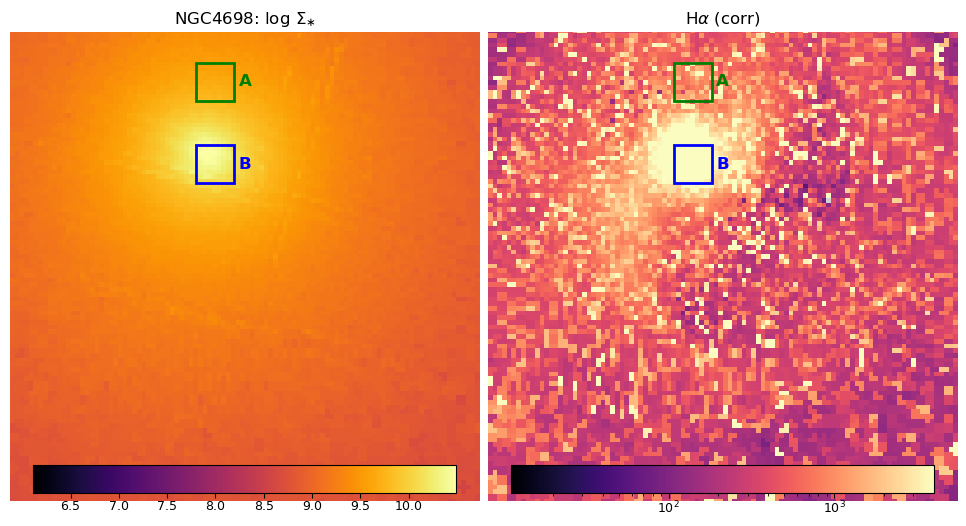

In [5]:
# --------------------------------------------------------------
# Maps: Σ_M* and corrected Hα flux for a single galaxy + boxed regions
# Data sources:
#  - Σ_M*: LOGMASS_SURFACE_DENSITY from *_SPATIAL_BINNING_maps_extended.fits
#  - Hα (corr): HA6562_FLUX_CORR (or HA6562_FLUX_corr) from *_gas_BIN_maps_extended.fits
# Overlays: two 8×8 spaxel (0.2"/spaxel) regions centered at specified WCS coords
# Zoom: central 100×100 spaxels
# Layout: 1 row × 2 columns: [Σ_M*, Hα_corr]
# --------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.colors import LogNorm
from matplotlib.patches import Rectangle
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u

# 0 · select galaxy
galaxies = ['NGC4698']
assert len(galaxies) == 1, "This cell is configured for a single galaxy."
gal = galaxies[0]

# Region definitions (centers)
coord_A = SkyCoord('12:48:22.89', '8:29:17.7', unit=(u.hourangle, u.deg), frame='icrs')
coord_B = SkyCoord('12:48:22.89', '8:29:14.2', unit=(u.hourangle, u.deg), frame='icrs')

# Each region: 8×8 spaxels (spaxel size 0.2") → use 8×8 pixels in the map grid
box_size_pix = 8
half_box = box_size_pix / 2

def load_mass_and_halpha_corr_and_wcs(gal):
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h_bin:
        logSigmaM = h_bin['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h_gas:
        # Try both common HDU name conventions (case varies across files)
        if 'HA6562_FLUX_CORR' in h_gas:
            ha_hdu = h_gas['HA6562_FLUX_CORR']
        elif 'HA6562_FLUX_corr' in h_gas:
            ha_hdu = h_gas['HA6562_FLUX_corr']
        else:
            raise KeyError("Cannot find Hα HDU: expected 'HA6562_FLUX_CORR' or 'HA6562_FLUX_corr'.")
        ha_corr = ha_hdu.data
        wcs = WCS(ha_hdu.header).celestial

    logSigmaM_c = np.where(np.isfinite(logSigmaM), logSigmaM, np.nan)
    ha_corr_c   = np.where(np.isfinite(ha_corr), ha_corr, np.nan)
    return logSigmaM_c, ha_corr_c, wcs

logSigmaM_c, ha_corr_c, wcs_cel = load_mass_and_halpha_corr_and_wcs(gal)

# For log colorbar, mask non-positive values (log undefined there)
ha_corr_log = np.where(ha_corr_c > 0, ha_corr_c, np.nan)

# Convert region centers from WCS → pixel coords (x, y)
xA, yA = wcs_cel.world_to_pixel(coord_A)
xB, yB = wcs_cel.world_to_pixel(coord_B)

def add_box(ax, x_center, y_center, label, color):
    rect = Rectangle(
        (x_center - half_box, y_center - half_box),
        box_size_pix, box_size_pix,
        fill=False, edgecolor=color, linewidth=2
    )
    ax.add_patch(rect)
    ax.text(x_center + half_box + 1, y_center, label, color=color, fontsize=12, weight='bold', va='center')

# Zoom window: central 100×100 spaxels
ny, nx = logSigmaM_c.shape
xc = (nx - 1) / 2
yc = (ny - 1) / 2
half_zoom = 50  # 100 spaxels across
xlim = (xc - half_zoom, xc + half_zoom)
ylim = (yc - half_zoom, yc + half_zoom)

# 1 row × 2 columns; make figure large enough for publication-style viewing
fig = plt.figure(figsize=(12, 5), constrained_layout=True)
gs  = GridSpec(nrows=1, ncols=2, figure=fig, width_ratios=[1, 1], wspace=0.00, hspace=0.00)

# Σ_M*
axM = fig.add_subplot(gs[0, 0])
cmap_M = plt.cm.inferno.copy(); cmap_M.set_bad('lightgray')
imM = axM.imshow(logSigmaM_c, origin='lower', cmap=cmap_M)
axM.set_title(rf'{gal}: $\log\,\Sigma_{{\ast}}$', fontsize=12)
axM.set_xlim(*xlim)
axM.set_ylim(*ylim)
axM.axis('off')
axM.set_anchor('E')  # push left panel to the right edge of its cell
add_box(axM, xA, yA, 'A', color='green')
add_box(axM, xB, yB, 'B', color='blue')
caxM = inset_axes(axM, width='90%', height='6%', loc='lower center', borderpad=0.6)
fig.colorbar(imM, cax=caxM, orientation='horizontal')
caxM.tick_params(labelsize=9, pad=1)

# Hα (corrected flux) with log-scaled colorbar
axHa = fig.add_subplot(gs[0, 1])
cmap_Ha = plt.cm.magma.copy(); cmap_Ha.set_bad('lightgray')

valid = np.isfinite(ha_corr_log)
if np.any(valid):
    vmin = np.nanpercentile(ha_corr_log[valid], 1)
    vmax = np.nanpercentile(ha_corr_log[valid], 99)
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin <= 0 or vmax <= vmin:
        vmin = np.nanmin(ha_corr_log[valid])
        vmax = np.nanmax(ha_corr_log[valid])
    imHa = axHa.imshow(ha_corr_log, origin='lower', cmap=cmap_Ha, norm=LogNorm(vmin=vmin, vmax=vmax))
else:
    print('Warning: No positive finite Hα values; using linear scale.')
    imHa = axHa.imshow(ha_corr_c, origin='lower', cmap=cmap_Ha)

axHa.set_title(r'H$\alpha$ (corr)', fontsize=12)
axHa.set_xlim(*xlim)
axHa.set_ylim(*ylim)
axHa.axis('off')
axHa.set_anchor('W')  # push right panel to the left edge of its cell
add_box(axHa, xA, yA, 'A', color='green')
add_box(axHa, xB, yB, 'B', color='blue')
caxHa = inset_axes(axHa, width='90%', height='6%', loc='lower center', borderpad=0.6)
fig.colorbar(imHa, cax=caxHa, orientation='horizontal')
caxHa.tick_params(labelsize=9, pad=1)

# fig.savefig('Plot_Paper_1/NGC4698_SigmaM_HalphaCorr_Maps_1x2_with_boxes_zoom100.png', dpi=600, bbox_inches='tight', pad_inches=0.05)
# fig.savefig('Plot_Paper_1/NGC4698_SigmaM_HalphaCorr_Maps_1x2_with_boxes_zoom100.pdf', dpi=600, bbox_inches='tight', pad_inches=0.05)

plt.show()


  NGC4698: 283391 HII pixels


/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_82926/2074833259.py:154: RuntimeWarning: divide by zero encountered in divide
  logN2_hii = np.log10(NII_common_HII / HA_common_HII)
/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_82926/2074833259.py:155: RuntimeWarning: divide by zero encountered in divide
  logO3_hii = np.log10(OIII_common_HII / HB_common_HII)
/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_82926/2074833259.py:155: RuntimeWarning: divide by zero encountered in log10
  logO3_hii = np.log10(OIII_common_HII / HB_common_HII)
/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_82926/2074833259.py:156: RuntimeWarning: divide by zero encountered in divide
  logS2_hii = np.log10((SII6716_common_HII + SII6730_common_HII) / HA_common_HII)
/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_82926/2074833259.py:156: RuntimeWarning: divide by zero encountered in log10
  logS2_hii = np.log10((SII6716_common_HII + SII6730_common_HII) / H


Total combined HII pixels: 283391
Region A highlighted points: 63
Region B highlighted points: 64

=== Combined BPT Diagram Summary (HII only) ===
  N2 BPT - Total HII: 154289 (54.4%)
  S2 BPT - Total HII: 80659 (28.5%)

Galaxy breakdown for HII spaxels:
  NGC4698: N2_HII=154289, S2_HII=80659

Successfully created combined BPT diagrams (HII only) colored by galaxy from 1 galaxies
Galaxies included: NGC4698


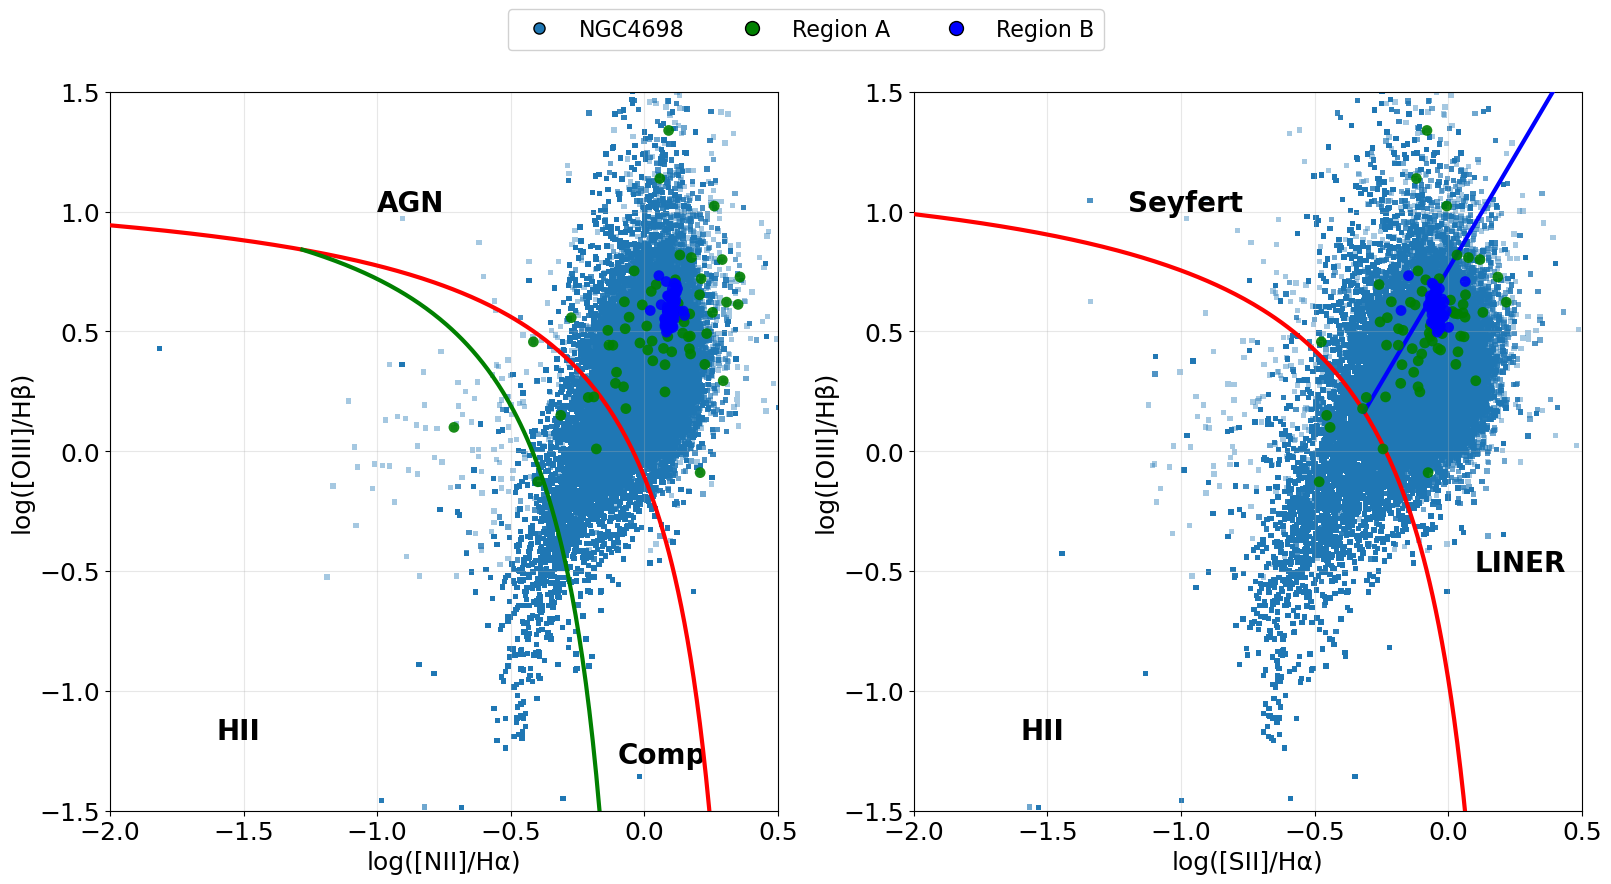

In [6]:
# ------------------------------------------------------------------
#
# Combined Analysis: NII and SII BPT Diagrams - Color-coded by Galaxy
#
# Collect all HII spaxels from all galaxies (HII only, no SF)
# Uses common spaxels across all 4 metallicity calibrations
#
# Additionally: highlight spaxels inside Region A (green) and Region B (blue)
# where A/B are 8×8-spaxel boxes centered at the specified WCS coordinates.
# ------------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path

from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u


# BPT reference line functions
def kewley01_N2(x):   # max-starburst
    return 0.61/(x-0.47) + 1.19


def kauff03_N2(x):    # empirical SF upper envelope
    return 0.61/(x-0.05) + 1.30


def kewley01_S2(x):
    return 0.72/(x-0.32) + 1.30


def kewley06_Sy_LIN(x):   # Seyfert/LINER division
    return 1.89*x + 0.76


# Create x arrays for the theoretical lines
x_kewley_N2 = np.linspace(-2.0, 0.3, 200)
x_kauff_N2 = np.linspace((286-np.sqrt(2871561))/1100, 0.0, 200)
x_kewley_S2 = np.linspace(-2.0, 0.3, 200)
x_kewley06_S2 = np.linspace((159-np.sqrt(105081))/525, 0.5, 200)


# Get all galaxies from binning files
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]
galaxies = ['NGC4698']


# Region definitions (centers)
coord_A = SkyCoord('12:48:22.89', '8:29:17.7', unit=(u.hourangle, u.deg), frame='icrs')
coord_B = SkyCoord('12:48:22.89', '8:29:14.2', unit=(u.hourangle, u.deg), frame='icrs')

# Each region: 8×8 spaxels → use 8×8 pixels in the map grid
box_size_pix = 8
half_box = box_size_pix // 2


def build_box_mask(shape, x_center, y_center, box_size):
    """Return a boolean mask selecting an `box_size`×`box_size` pixel box.

    Center is rounded to nearest integer pixel.
    """
    ny, nx = shape
    xc = int(np.round(x_center))
    yc = int(np.round(y_center))
    half = box_size // 2

    xmin = max(xc - half, 0)
    xmax = min(xc + half, nx)
    ymin = max(yc - half, 0)
    ymax = min(yc + half, ny)

    m = np.zeros((ny, nx), dtype=bool)
    m[ymin:ymax, xmin:xmax] = True
    return m


# Create galaxy color mapping (consistent for all HII regions)
galaxy_colors = plt.cm.tab20(np.linspace(0, 1, len(galaxies)))
galaxy_color_dict = dict(zip(galaxies, galaxy_colors))


# Collect all spaxels from all galaxies - HII only (with galaxy indices)
all_logN2_hii = []
all_logO3_hii = []
all_logS2_hii = []
all_galaxy_indices_hii = []

# Collect highlighted region points (across galaxies)
all_logN2_A, all_logO3_A, all_logS2_A = [], [], []
all_logN2_B, all_logO3_B, all_logS2_B = [], [], []


print("Collecting HII data from all galaxies...")

for gal_idx, gal in enumerate(galaxies):

    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')
    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')

    if gas_file.exists() and bin_file.exists():
        # Load maps for this galaxy
        with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
            logSigmaM = h['LOGMASS_SURFACE_DENSITY'].data

        with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
            # HII quantities
            logSigmaSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
            oh_d16_HII = h['O_H_D16_HII'].data
            oh_pg16_HII = h['O_H_PG16_HII'].data
            oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
            oh_o3n2_c20_HII = h['O_H_O3N2_C20_HII'].data

            # Load corrected emission line fluxes
            HB4861_FLUX_corr = h['HB4861_FLUX_corr'].data

            # Hα HDU name varies; also used for WCS
            if 'HA6562_FLUX_CORR' in h:
                ha_hdu = h['HA6562_FLUX_CORR']
            elif 'HA6562_FLUX_corr' in h:
                ha_hdu = h['HA6562_FLUX_corr']
            else:
                raise KeyError("Cannot find Hα HDU: expected 'HA6562_FLUX_CORR' or 'HA6562_FLUX_corr'.")

            HA6562_FLUX_corr = ha_hdu.data
            wcs_cel = WCS(ha_hdu.header).celestial

            OIII5006_FLUX_corr = h['OIII5006_FLUX_corr'].data
            NII6583_FLUX_corr = h['NII6583_FLUX_corr'].data
            SII6716_FLUX_corr = h['SII6716_FLUX_corr'].data
            SII6730_FLUX_corr = h['SII6730_FLUX_corr'].data

        # Find common spaxels for HII
        common_mask_HII = (np.isfinite(HB4861_FLUX_corr) & np.isfinite(HA6562_FLUX_corr) &
                           np.isfinite(OIII5006_FLUX_corr) & np.isfinite(NII6583_FLUX_corr) &
                           np.isfinite(SII6716_FLUX_corr) & np.isfinite(SII6730_FLUX_corr))

        n_pixels_HII = np.sum(common_mask_HII)
        print(f"  {gal}: {n_pixels_HII} HII pixels")

        # Apply common_mask to get valid spaxels - HII
        HB_common_HII = HB4861_FLUX_corr[common_mask_HII]
        HA_common_HII = HA6562_FLUX_corr[common_mask_HII]
        OIII_common_HII = OIII5006_FLUX_corr[common_mask_HII]
        NII_common_HII = NII6583_FLUX_corr[common_mask_HII]
        SII6716_common_HII = SII6716_FLUX_corr[common_mask_HII]
        SII6730_common_HII = SII6730_FLUX_corr[common_mask_HII]

        # Calculate line ratios - HII
        logN2_hii = np.log10(NII_common_HII / HA_common_HII)
        logO3_hii = np.log10(OIII_common_HII / HB_common_HII)
        logS2_hii = np.log10((SII6716_common_HII + SII6730_common_HII) / HA_common_HII)

        # Append to combined arrays - HII only
        all_logN2_hii.extend(logN2_hii.flatten())
        all_logO3_hii.extend(logO3_hii.flatten())
        all_logS2_hii.extend(logS2_hii.flatten())
        all_galaxy_indices_hii.extend([gal_idx] * len(logN2_hii.flatten()))

        # ---- Region A/B highlight points (subset of common_mask_HII) ----
        xA, yA = wcs_cel.world_to_pixel(coord_A)
        xB, yB = wcs_cel.world_to_pixel(coord_B)

        maskA = build_box_mask(HA6562_FLUX_corr.shape, xA, yA, box_size_pix)
        maskB = build_box_mask(HA6562_FLUX_corr.shape, xB, yB, box_size_pix)

        regionA = common_mask_HII & maskA
        regionB = common_mask_HII & maskB

        # Region A ratios
        if np.any(regionA):
            HB_A = HB4861_FLUX_corr[regionA]
            HA_A = HA6562_FLUX_corr[regionA]
            OIII_A = OIII5006_FLUX_corr[regionA]
            NII_A = NII6583_FLUX_corr[regionA]
            S2_A = (SII6716_FLUX_corr[regionA] + SII6730_FLUX_corr[regionA])

            okA = (HB_A > 0) & (HA_A > 0) & (OIII_A > 0) & (NII_A > 0) & (S2_A > 0)
            if np.any(okA):
                all_logN2_A.extend(np.log10(NII_A[okA] / HA_A[okA]).tolist())
                all_logO3_A.extend(np.log10(OIII_A[okA] / HB_A[okA]).tolist())
                all_logS2_A.extend(np.log10(S2_A[okA] / HA_A[okA]).tolist())

        # Region B ratios
        if np.any(regionB):
            HB_B = HB4861_FLUX_corr[regionB]
            HA_B = HA6562_FLUX_corr[regionB]
            OIII_B = OIII5006_FLUX_corr[regionB]
            NII_B = NII6583_FLUX_corr[regionB]
            S2_B = (SII6716_FLUX_corr[regionB] + SII6730_FLUX_corr[regionB])

            okB = (HB_B > 0) & (HA_B > 0) & (OIII_B > 0) & (NII_B > 0) & (S2_B > 0)
            if np.any(okB):
                all_logN2_B.extend(np.log10(NII_B[okB] / HA_B[okB]).tolist())
                all_logO3_B.extend(np.log10(OIII_B[okB] / HB_B[okB]).tolist())
                all_logS2_B.extend(np.log10(S2_B[okB] / HA_B[okB]).tolist())

    else:
        print(f"  {gal}: Data files not found")


# Convert to numpy arrays - HII
all_logN2_hii = np.array(all_logN2_hii)
all_logO3_hii = np.array(all_logO3_hii)
all_logS2_hii = np.array(all_logS2_hii)
all_galaxy_indices_hii = np.array(all_galaxy_indices_hii)

# Convert region highlight arrays
all_logN2_A = np.array(all_logN2_A)
all_logO3_A = np.array(all_logO3_A)
all_logS2_A = np.array(all_logS2_A)

all_logN2_B = np.array(all_logN2_B)
all_logO3_B = np.array(all_logO3_B)
all_logS2_B = np.array(all_logS2_B)


print(f"\nTotal combined HII pixels: {len(all_logN2_hii)}")
print(f"Region A highlighted points: {len(all_logN2_A)}")
print(f"Region B highlighted points: {len(all_logN2_B)}")


# Apply BPT classifications - HII only
mask_N2_HII = all_logO3_hii <= kauff03_N2(all_logN2_hii)
mask_N2_Comp = (all_logO3_hii > kauff03_N2(all_logN2_hii)) & (all_logO3_hii <= kewley01_N2(all_logN2_hii))
mask_N2_AGN = all_logO3_hii > kewley01_N2(all_logN2_hii)

mask_S2_HII = all_logO3_hii <= kewley01_S2(all_logS2_hii)
mask_S2_above_kewley = all_logO3_hii > kewley01_S2(all_logS2_hii)
mask_S2_LINER = mask_S2_above_kewley & (all_logO3_hii <= kewley06_Sy_LIN(all_logS2_hii))
mask_S2_Seyfert = mask_S2_above_kewley & (all_logO3_hii > kewley06_Sy_LIN(all_logS2_hii))

mask_HII_N2 = mask_N2_HII | mask_N2_Comp
mask_HII_S2 = mask_S2_HII


# Create BPT diagrams: HII only (single row, two panels)
# Use constrained_layout for better spacing with legend
fig, axes = plt.subplots(1, 2, figsize=(16, 8), constrained_layout=True)


# ===== HII REGIONS ONLY =====

# NII BPT Diagram - HII
ax = axes[0]

for gal_idx, gal in enumerate(galaxies):
    gal_mask = (all_galaxy_indices_hii == gal_idx)
    if np.sum(gal_mask) > 0:
        ax.scatter(all_logN2_hii[gal_mask], all_logO3_hii[gal_mask],
                   color=galaxy_colors[gal_idx], marker=',', s=15, alpha=0.4,
                   edgecolors='none', rasterized=True)

# Highlight Region A/B
if len(all_logN2_A) > 0:
    ax.scatter(all_logN2_A, all_logO3_A, s=60, color='green', marker='o', alpha=0.9,
               edgecolors='none', zorder=25)
if len(all_logN2_B) > 0:
    ax.scatter(all_logN2_B, all_logO3_B, s=60, color='blue', marker='o', alpha=0.9,
               edgecolors='none', zorder=26)

ax.plot(x_kewley_N2, kewley01_N2(x_kewley_N2), 'r-', lw=3, label='Kewley+01', zorder=10)
ax.plot(x_kauff_N2, kauff03_N2(x_kauff_N2), 'g-', lw=3, label='Kauffmann+03', zorder=10)

hii_count_N2 = np.sum(mask_HII_N2)
total_common_hii = len(all_logN2_hii)
hii_percent_N2 = hii_count_N2 / total_common_hii * 100 if total_common_hii > 0 else 0

ax.set_xlabel('log([NII]/Hα)', fontsize=18)
ax.set_ylabel('log([OIII]/Hβ)', fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.set_xlim(-2.0, 0.5)
ax.set_ylim(-1.5, 1.5)

# ax.set_title('NII BPT (Common HII spaxels by Galaxy)', fontsize=14)
ax.text(-1.6, -1.2, 'HII', fontsize=20, fontweight='bold')
ax.text(-0.1, -1.3, 'Comp', fontsize=20, fontweight='bold')
ax.text(-1.0, 1.0, 'AGN', fontsize=20, fontweight='bold')
ax.grid(True, alpha=0.3)


# SII BPT Diagram - HII
ax = axes[1]

for gal_idx, gal in enumerate(galaxies):
    gal_mask = (all_galaxy_indices_hii == gal_idx)
    if np.sum(gal_mask) > 0:
        ax.scatter(all_logS2_hii[gal_mask], all_logO3_hii[gal_mask],
                   color=galaxy_colors[gal_idx], marker=',', s=15, alpha=0.4,
                   edgecolors='none', rasterized=True)

# Highlight Region A/B
if len(all_logS2_A) > 0:
    ax.scatter(all_logS2_A, all_logO3_A, s=60, color='green', marker='o', alpha=0.9,
               edgecolors='none', zorder=25)
if len(all_logS2_B) > 0:
    ax.scatter(all_logS2_B, all_logO3_B, s=60, color='blue', marker='o', alpha=0.9,
               edgecolors='none', zorder=26)

ax.plot(x_kewley_S2, kewley01_S2(x_kewley_S2), 'r-', lw=3, label='Kewley+01', zorder=10)
ax.plot(x_kewley06_S2, kewley06_Sy_LIN(x_kewley06_S2), 'b-', lw=3, label='Kewley+06', zorder=10)

hii_count_S2 = np.sum(mask_HII_S2)
hii_percent_S2 = hii_count_S2 / total_common_hii * 100 if total_common_hii > 0 else 0

ax.set_xlabel('log([SII]/Hα)', fontsize=18)
ax.set_ylabel('log([OIII]/Hβ)', fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.set_xlim(-2.0, 0.5)
ax.set_ylim(-1.5, 1.5)

# ax.set_title('SII BPT (Common HII spaxels by Galaxy)', fontsize=14)
ax.text(-1.6, -1.2, 'HII', fontsize=20, fontweight='bold')
ax.text(-1.2, 1.0, 'Seyfert', fontsize=20, fontweight='bold')
ax.text(0.1, -0.5, 'LINER', fontsize=20, fontweight='bold')
ax.grid(True, alpha=0.3)


# Build custom legend handles with larger markers
legend_handles = []
legend_labels = []

for gal_idx, gal in enumerate(galaxies):
    legend_handles.append(Line2D([0], [0], marker='o', color='none',
                                 markerfacecolor=galaxy_colors[gal_idx], markersize=8, linestyle='None'))
    legend_labels.append(f'{gal}')

# Add region markers to legend
legend_handles.append(Line2D([0], [0], marker='o', color='none',
                             markerfacecolor='green', markersize=10, linestyle='None'))
legend_labels.append('Region A')
legend_handles.append(Line2D([0], [0], marker='o', color='none',
                             markerfacecolor='blue', markersize=10, linestyle='None'))
legend_labels.append('Region B')


# Put legend above the axes at 1.1 (outside plot)
fig.legend(legend_handles, legend_labels, loc='upper center',
           bbox_to_anchor=(0.5, 1.1),
           ncol=min(len(legend_labels), 7), fontsize=16, framealpha=0.9)


# Save PNG tightly cropped, PDF with standard bbox (no cropping of legend)
# fig.savefig('Plot_Paper_1/Combined_BPT_diagrams_by_Galaxy_HII.png', dpi=600, bbox_inches='tight', pad_inches=0.05)
# fig.savefig('Plot_Paper_1/Combined_BPT_diagrams_by_Galaxy_HII.pdf', dpi=600, bbox_inches='tight', pad_inches=0.05)


# Print summary statistics (HII only)
print(f"\n=== Combined BPT Diagram Summary (HII only) ===")
print(f"  N2 BPT - Total HII: {hii_count_N2} ({hii_percent_N2:.1f}%)")
print(f"  S2 BPT - Total HII: {hii_count_S2} ({hii_percent_S2:.1f}%)")


# Print galaxy breakdown for HII spaxels
print(f"\nGalaxy breakdown for HII spaxels:")
for gal_idx, gal in enumerate(galaxies):
    gal_n2 = np.sum((all_galaxy_indices_hii == gal_idx) & mask_HII_N2)
    gal_s2 = np.sum((all_galaxy_indices_hii == gal_idx) & mask_HII_S2)
    print(f"  {gal}: N2_HII={gal_n2}, S2_HII={gal_s2}")


print(f"\nSuccessfully created combined BPT diagrams (HII only) colored by galaxy from {len(galaxies)} galaxies")
print(f"Galaxies included: {', '.join(galaxies)}")

plt.show()
